# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## Практическая работа 3. Поиск аномалий во временных рядах


### Подготовка окружения и ноутбука

In [1]:
import os
from pathlib import Path

practice_dir_path = Path(os.getcwd()).absolute()
print(practice_dir_path)

os.chdir(practice_dir_path)

c:\Users\admin\Projects\labs\5\3\tsc\practice\03 Discords


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import colorsys
from saxpy.znorm import znorm
from saxpy.sax import sax_via_window
from saxpy.distance import euclidean
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump

from modules.saxpy.discord import find_discords_brute_force
from modules.drag import DRAG, find_candidates, refine_candidates

c:\Users\admin\Projects\labs\5\3\tsc\.venv\Lib\site-packages\stumpy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


### **3.1.** Поиск диссонансов с помощью алгоритма HotSAX

#### **3.1.1.** Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.

In [4]:
#fixme: Путь
dataset_dir_path = Path('./datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

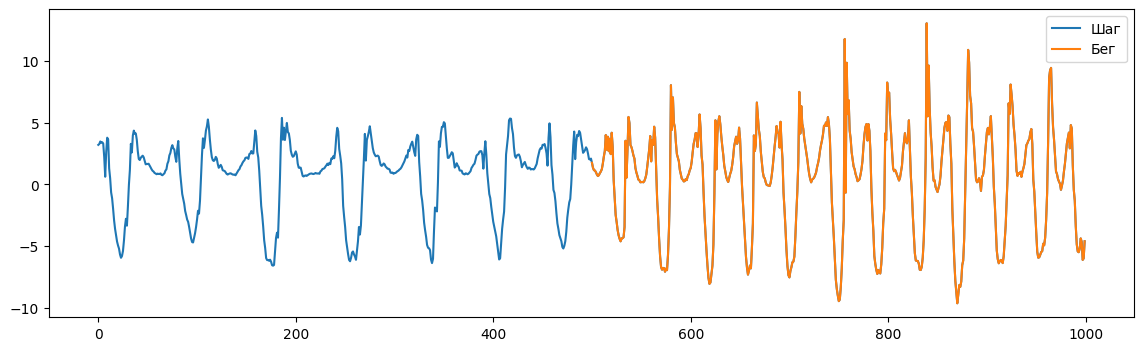

In [5]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [6]:
result={}
times={}

#### **3.1.2.** Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [7]:
start = time()
discords_brute_force = np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

In [8]:
result['bruteForce'] = discords_brute_force
times['bruteForce'] = end - start

#### **3.1.3.** HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [9]:
def find_discords_hotsax(series, win_size=100, num_discords=2, alphabet_size=3,
                         paa_size=3, znorm_threshold=0.01, sax_type='unidim'):
    """HOT-SAX-driven discords discovery."""
    discords = list()

    global_registry = set()

    # Z-normalized versions for every subsequence.
    znorms = np.array([znorm(series[pos: pos + win_size], znorm_threshold) for pos in range(len(series) - win_size + 1)])

    # SAX words for every subsequence.
    sax_data = sax_via_window(series, win_size=win_size, paa_size=paa_size, alphabet_size=alphabet_size,
                              nr_strategy=None, z_threshold=0.01)

    """[2.0] build the 'magic' array"""
    magic_array = list()
    for k, v in sax_data.items():
        magic_array.append((k, len(v)))

    """[2.1] sort it ascending by the number of occurrences"""
    magic_array = sorted(magic_array, key=lambda tup: tup[1])

    while len(discords) < num_discords:

        best_discord = find_best_discord_hotsax(series, win_size, global_registry, sax_data, magic_array, znorms)

        if -1 == best_discord[0]:
            break

        discords.append(best_discord)

        mark_start = max(0, best_discord[0] - win_size + 1)
        mark_end = best_discord[0] + win_size

        for i in range(mark_start, mark_end):
            global_registry.add(i)

    return discords


def find_best_discord_hotsax(series, win_size, global_registry, sax_data, magic_array, znorms):
    """Find the best discord with hotsax."""

    """[3.0] define the key vars"""
    best_so_far_position = -1
    best_so_far_distance = 0.

    distance_calls = 0

    visit_array = np.zeros(len(series), dtype=int)

    """[4.0] and we are off iterating over the magic array entries"""
    for entry in magic_array:

        """[5.0] current SAX words and the number of other sequences mapping to the same SAX word."""
        curr_word = entry[0]
        occurrences = sax_data[curr_word]

        """[6.0] jumping around by the same word occurrences makes it easier to
        nail down the possibly small distance value -- so we can be efficient
        and all that..."""
        for curr_pos in occurrences:

            if curr_pos in global_registry:
                continue

            """[7.0] we don't want an overlapping subsequence"""
            mark_start = curr_pos - win_size + 1
            mark_end = curr_pos + win_size
            visit_set = set(range(mark_start, mark_end))

            """[8.0] here is our subsequence in question"""
            cur_seq = znorms[curr_pos]

            """[9.0] let's see what is NN distance"""
            nn_dist = np.inf
            do_random_search = True

            """[10.0] ordered by occurrences search first"""
            for next_pos in occurrences:

                """[11.0] skip bad pos"""
                if next_pos in visit_set:
                    continue
                else:
                    visit_set.add(next_pos)

                """[12.0] distance we compute"""

                dist = euclidean(cur_seq, znorms[next_pos])
                distance_calls += 1

                """[13.0] keep the books up-to-date"""
                if dist < nn_dist:
                    nn_dist = dist
                if dist < best_so_far_distance:
                    do_random_search = False
                    break

            """[13.0] if not broken above,
            we shall proceed with random search"""
            if do_random_search:
                """[14.0] build that random visit order array"""
                curr_idx = 0
                for i in range(0, (len(series) - win_size + 1)):
                    if not(i in visit_set):
                        visit_array[curr_idx] = i
                        curr_idx += 1
                it_order = np.random.permutation(visit_array[0:curr_idx])
                curr_idx -= 1

                """[15.0] and go random"""
                while curr_idx >= 0:
                    rand_pos = it_order[curr_idx]
                    curr_idx -= 1

                    dist = euclidean(cur_seq, znorms[rand_pos])
                    distance_calls += 1

                    """[16.0] keep the books up-to-date again"""
                    if dist < nn_dist:
                        nn_dist = dist
                    if dist < best_so_far_distance:
                        nn_dist = dist
                        break

            """[17.0] and BIGGER books"""
            if (nn_dist > best_so_far_distance) and (nn_dist < np.inf):
                best_so_far_distance = nn_dist
                best_so_far_position = curr_pos

    return best_so_far_position, best_so_far_distance

In [10]:
start = time()
discrods_hot_sax =  np.stack(find_discords_hotsax(data[:], 50, 5))
end = time()

In [11]:
result['hotSax'] = discrods_hot_sax
times['hotSax'] = end - start

#### **3.1.4.** Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

In [12]:
def distinct_colors(num_colors: int) -> list[str]:
    """Создает равномерно распределённые по цветовому кругу RGB-цвета."""
    hsv_colors = [(i / num_colors, 0.8, 0.9) for i in range(num_colors)]
    return [colorsys.hsv_to_rgb(*hsv) for hsv in hsv_colors]

def visualise_results(data, result, times, win_size=50):
    algorithms = list(result.keys())
    n = len(algorithms)

    algo_colors = distinct_colors(n)

    # === Фигура ===
    fig = plt.figure(figsize=(16, 5 + 3 * n))
    gs = fig.add_gridspec(n, 2, width_ratios=[3, 1])

    # ==== ГРАФИКИ ВРЕМЕННЫХ РЯДОВ ====
    for i, algo in enumerate(algorithms):
        ax = fig.add_subplot(gs[i, 0])

        # Сохраняем исходные цвета временного ряда
        if data.ndim == 1:
            ax.plot(data, label='Временной ряд', color='blue')
        else:
            for j in range(data.shape[1]):
                ax.plot(data[:, j], label=f'Серия {j + 1}')

        # Дискорды для конкретного алгоритма
        for discord in result[algo]:
            start_idx = int(discord[0])
            ax.axvspan(
                start_idx, start_idx + win_size,
                color=algo_colors[i], alpha=0.35,
                label=f'Дискорды ({algo})'
            )

        # Легенда без дублей
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right')

        ax.set_title(f"Временной ряд с дискордами ({algo})", color=algo_colors[i])
        ax.set_xlabel("Индекс")
        ax.set_ylabel("Значение")

    # ==== СТОЛБЧАТАЯ ДИАГРАММА ВРЕМЕНИ ====
    ax_bar = fig.add_subplot(gs[:, 1])  # Правая колонка на всю высоту
    ax_bar.bar(
        algorithms,
        [times[a] for a in algorithms],
        color=algo_colors,
        edgecolor='black'
    )
    ax_bar.set_ylabel("Время выполнения (секунды)")
    ax_bar.set_title("Сравнение времени выполнения алгоритмов", fontsize=13)

    plt.tight_layout()
    plt.show()

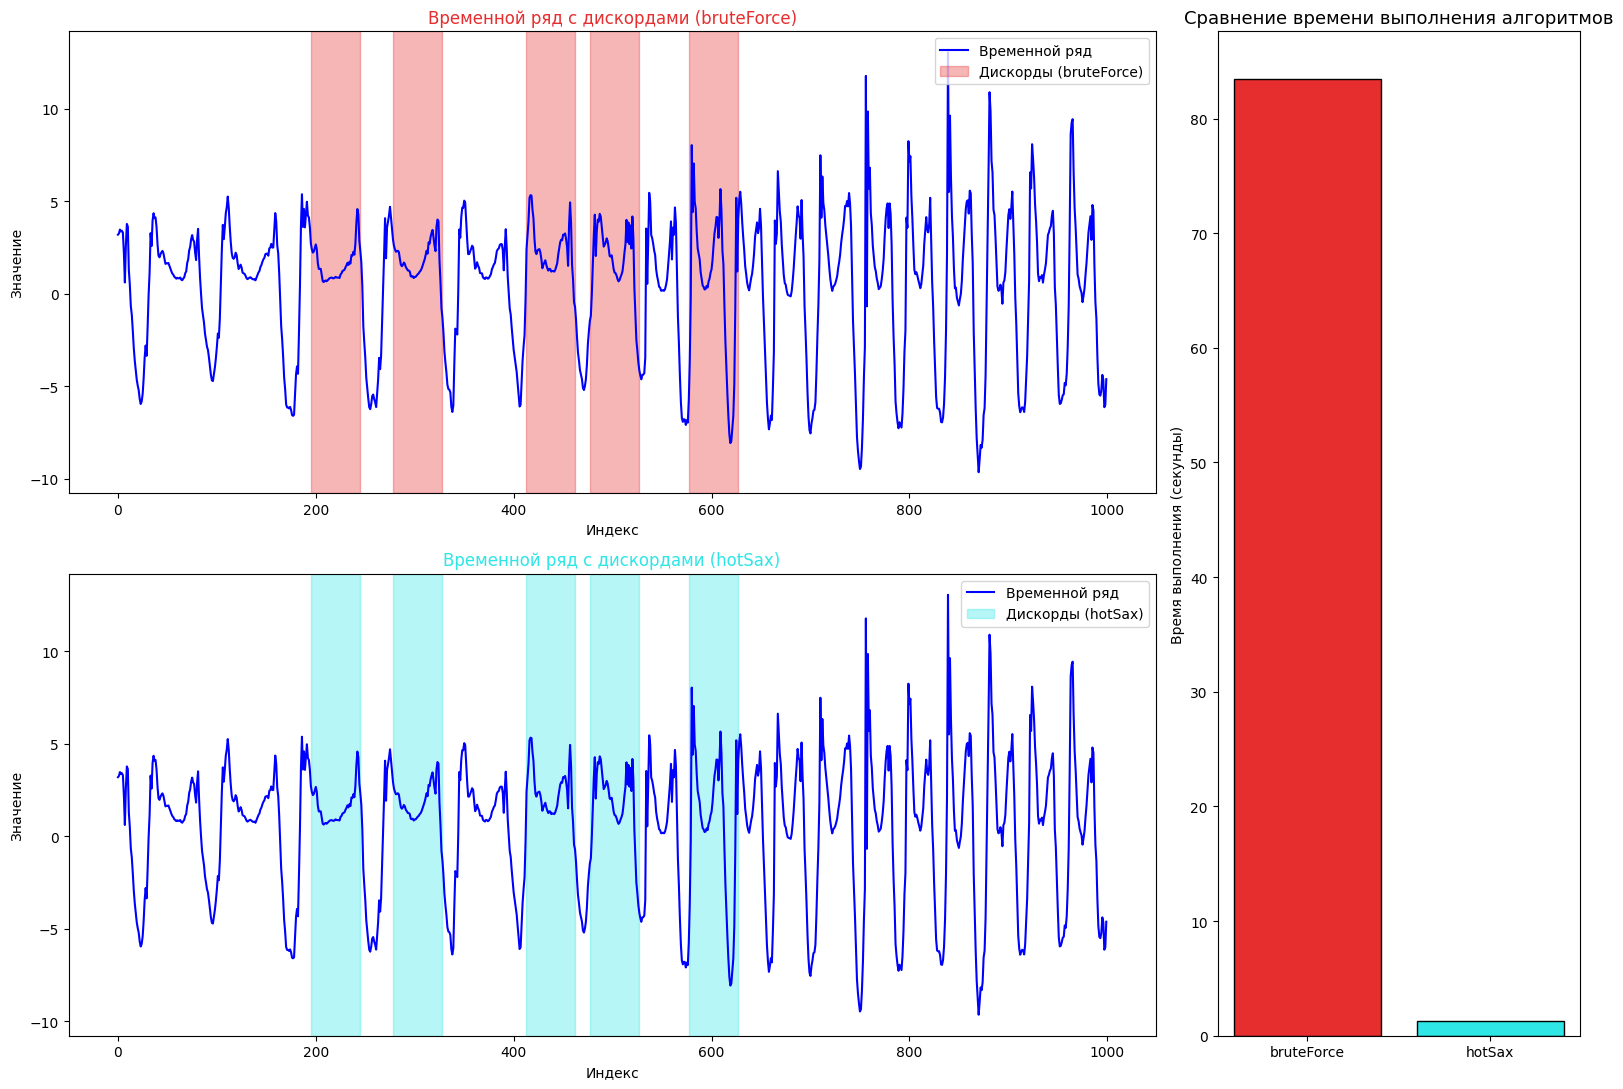

In [13]:
visualise_results(data, result, times, win_size=50)

#### **3.1.5.** Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

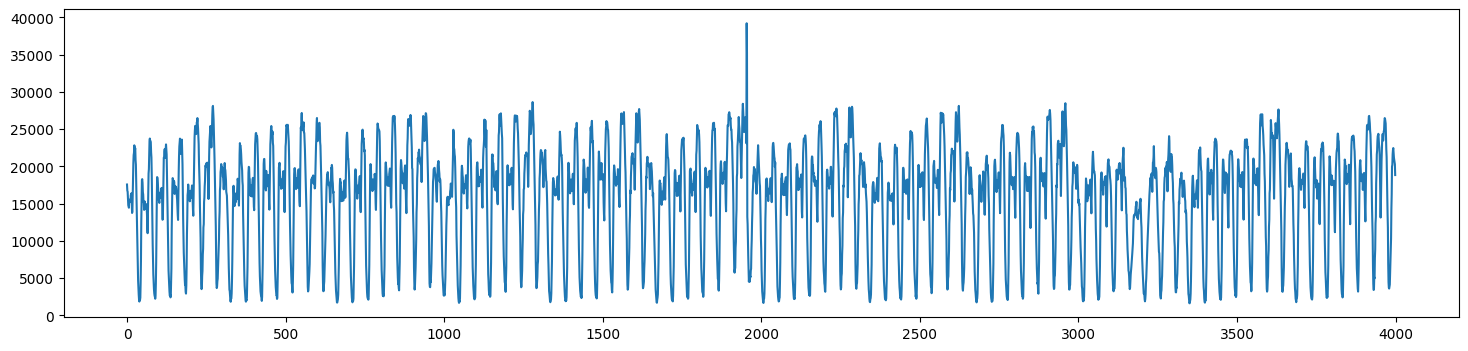

In [88]:
nyt_data = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyt_data)

In [89]:
nyt_results = {}
nyt_times = {}

In [ ]:
start = time()
discords_brute_force = np.stack(find_discords_brute_force(nyt_data[:], 200, 5))
end = time()
nyt_results['BruteForce'] = discords_brute_force
nyt_times['BruteForce'] = end - start

In [90]:
start = time()
discords_hot_sax = np.stack(find_discords_hotsax(nyt_data[:], 200, 5))
end = time()
nyt_results['HotSAX'] = discords_hot_sax
nyt_times['HotSAX'] = end - start

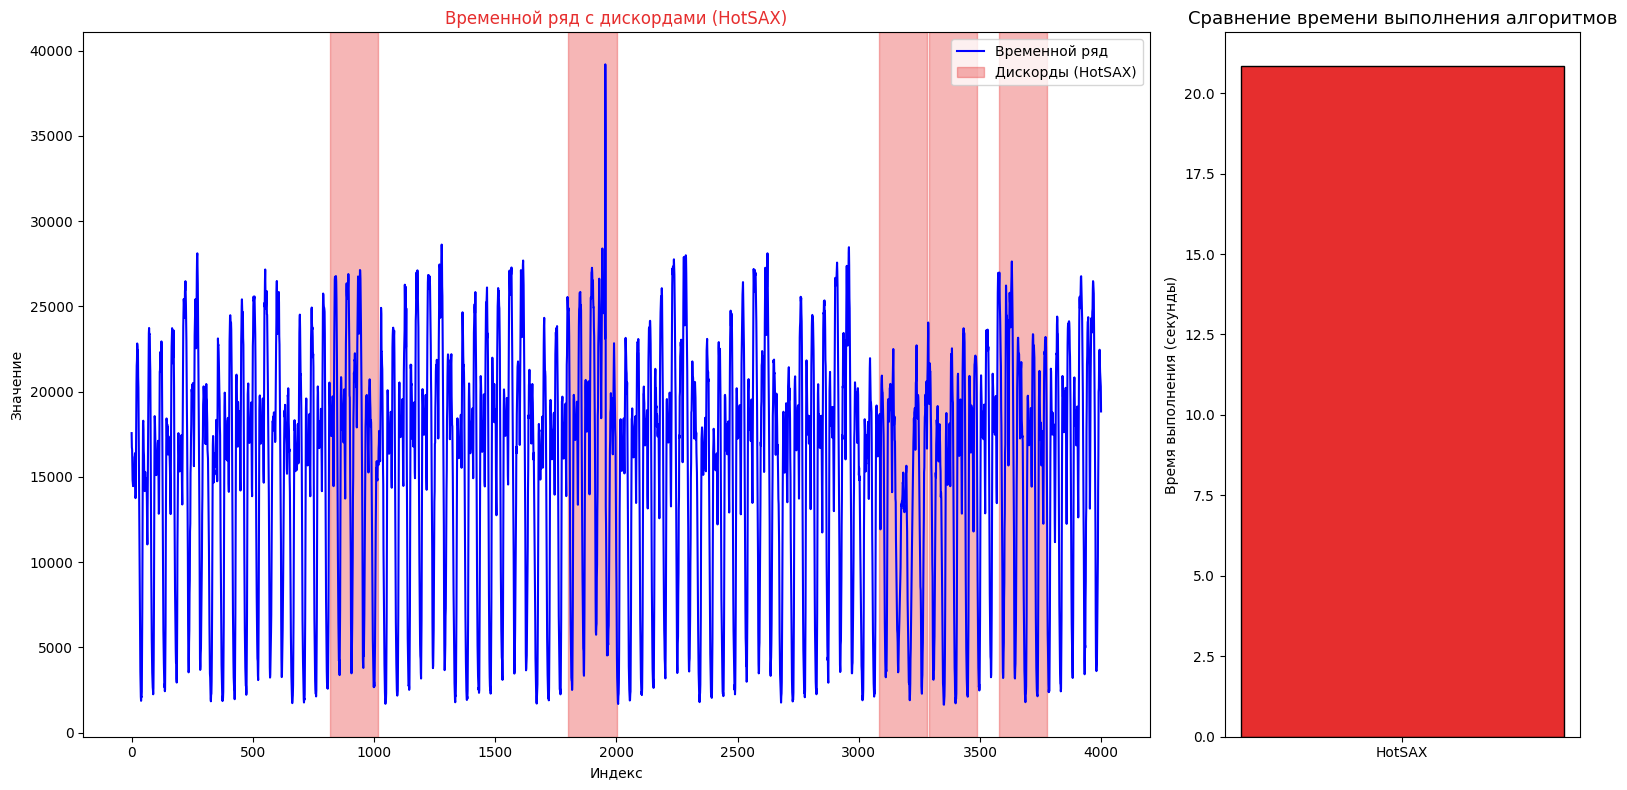

In [ ]:
visualise_results(nyt_data, nyt_results, nyt_times, win_size=200)

### **3.2.** Поиск диссонансов с помощью алгоритма DRAG

#### **3.2.0.**

Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [19]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [20]:
m = 50
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [21]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [23]:
m = 50
r = 1
idxs, _, _ = DRAG(nyt_data,m,r)

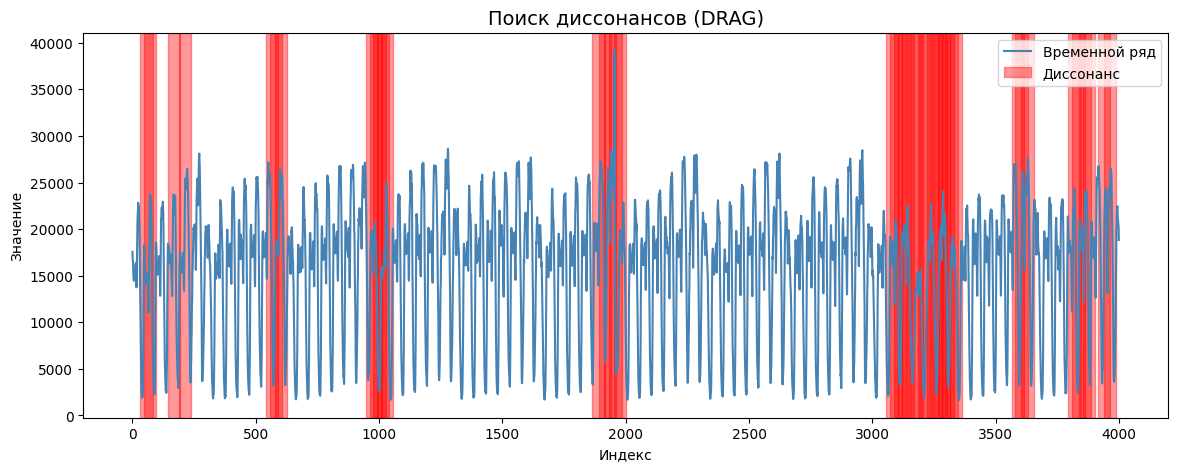

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(nyt_data, label='Временной ряд', color='steelblue')

for i, idx in enumerate(idxs):
    plt.axvspan(idx, idx + m, color='red', alpha=0.4, label='Диссонанс' if i == 0 else "")

plt.title('Поиск диссонансов (DRAG)', fontsize=14)
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.legend(loc='upper right')
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

#### **3.2.1.** Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [25]:
#выбирем более реальное значение для порога
r = 3

In [26]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [27]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

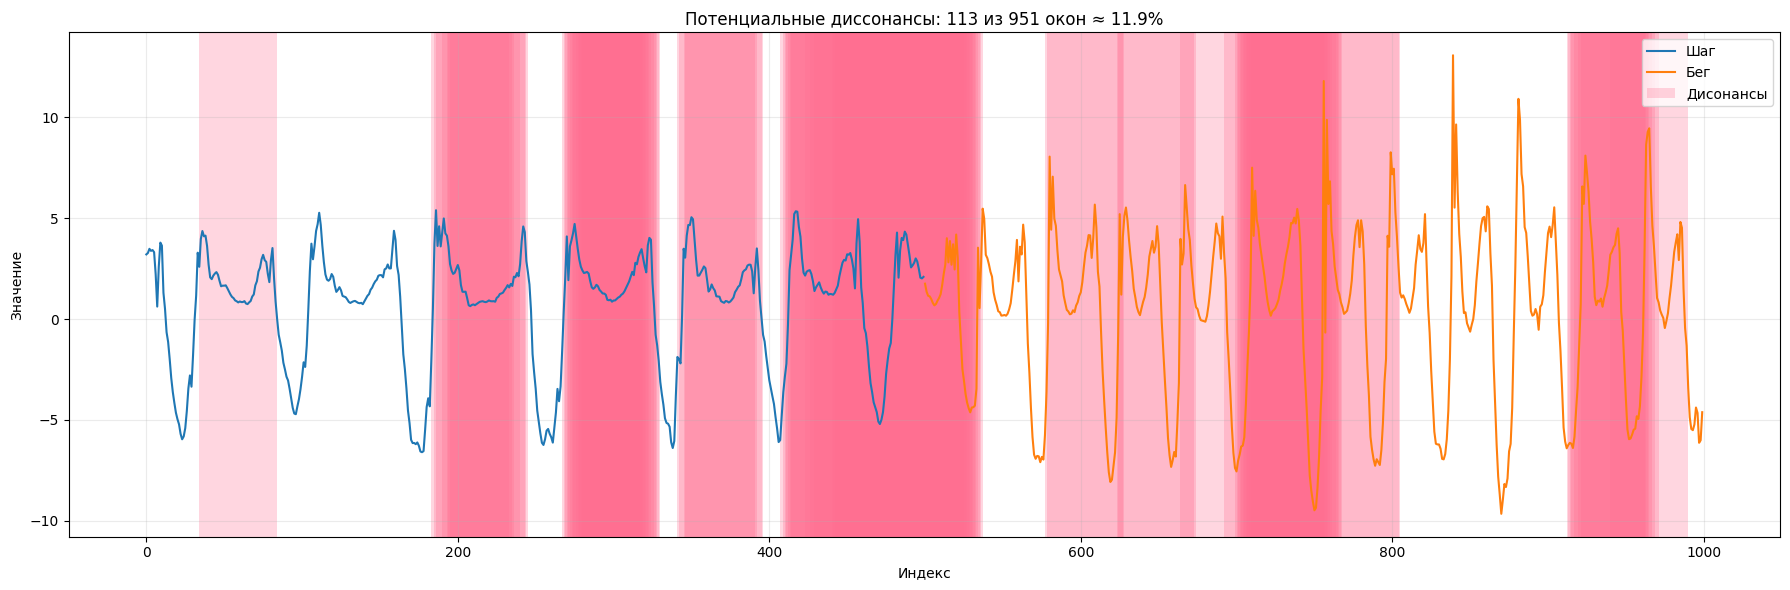

In [28]:
n = len(data)
n_win = n - m + 1
pct = 100 * len(cand_index) / n_win

fig, ax = plt.subplots(figsize=(18, 6))

mid = n // 2
ax.plot(np.arange(0, mid), data[:mid], label='Шаг', lw=1.5)
ax.plot(np.arange(mid, n), data[mid:], label='Бег', lw=1.5)

for i, idx in enumerate(cand_index):
    ax.axvspan(idx, idx + m, color='#ff6f91', alpha=0.28, lw=0,
               label='Дисонансы' if i == 0 else None)

ax.set_title(f'Потенциальные диссонансы: '
             f'{len(cand_index)} из {n_win} окон ≈ {pct:.1f}%', fontsize=12)
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### **3.2.2.** Очистка кандидатов

Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.

In [29]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [30]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

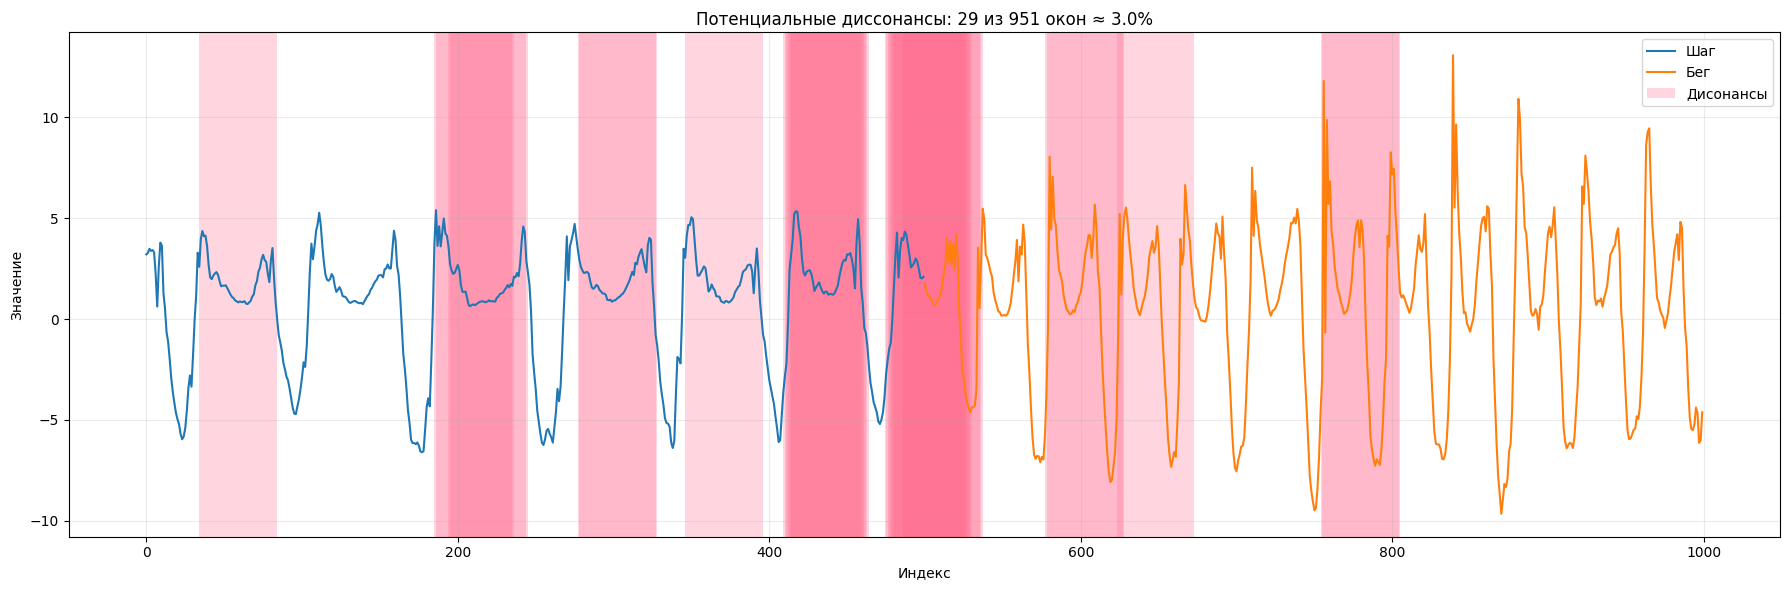

In [31]:
n = len(data)
n_win = n - m + 1
pct = 100 * len(cands) / n_win

fig, ax = plt.subplots(figsize=(18, 6))

mid = n // 2
ax.plot(np.arange(0, mid), data[:mid], label='Шаг', lw=1.5)
ax.plot(np.arange(mid, n), data[mid:], label='Бег', lw=1.5)

for i, idx in enumerate(cands):
    ax.axvspan(idx, idx + m, color='#ff6f91', alpha=0.28, lw=0,
               label='Дисонансы' if i == 0 else None)

ax.set_title(f'Потенциальные диссонансы: '
             f'{len(cands)} из {n_win} окон ≈ {pct:.1f}%', fontsize=12)
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [32]:
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

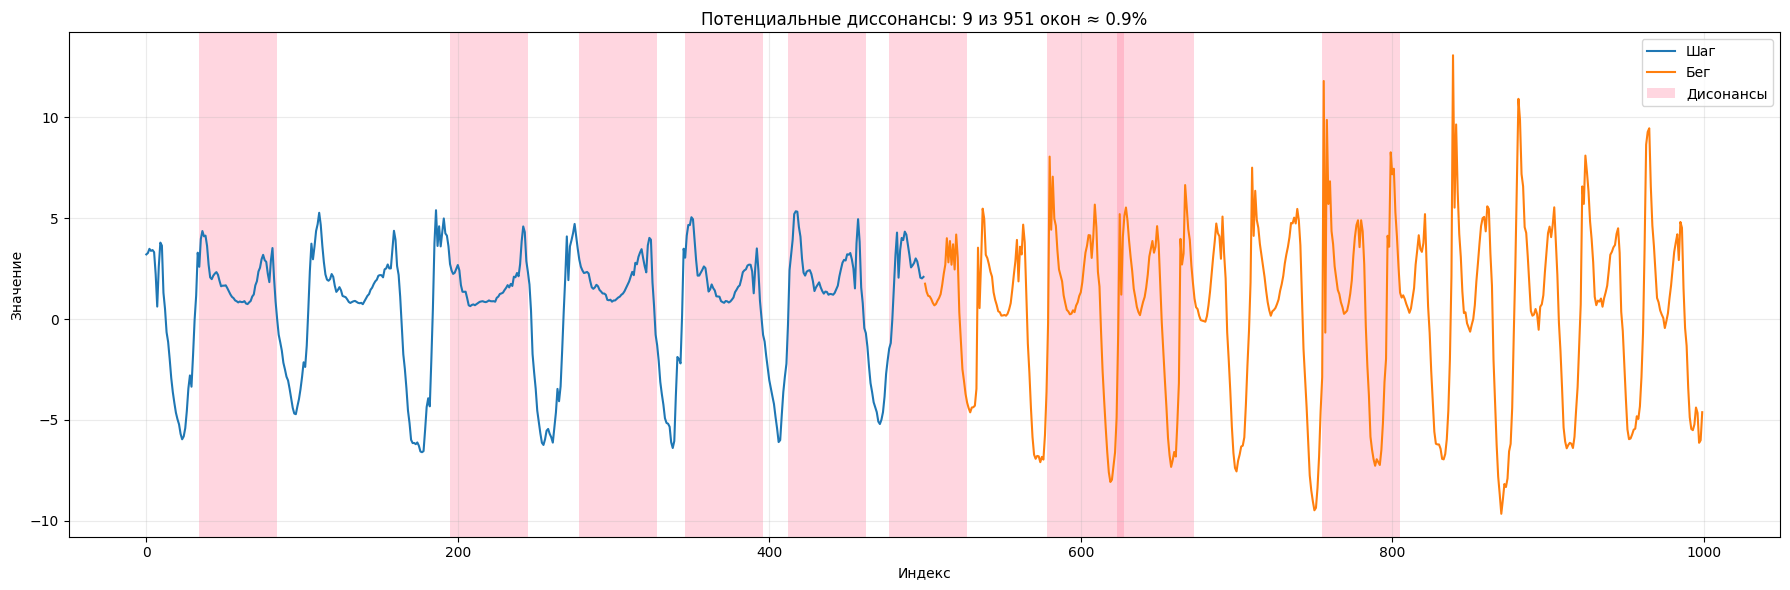

In [33]:
n = len(data)
n_win = n - m + 1
pct = 100 * len(discords_idx) / n_win

fig, ax = plt.subplots(figsize=(18, 6))

mid = n // 2
ax.plot(np.arange(0, mid), data[:mid], label='Шаг', lw=1.5)
ax.plot(np.arange(mid, n), data[mid:], label='Бег', lw=1.5)

for i, idx in enumerate(discords_idx):
    ax.axvspan(idx, idx + m, color='#ff6f91', alpha=0.28, lw=0,
               label='Дисонансы' if i == 0 else None)

ax.set_title(f'Потенциальные диссонансы: '
             f'{len(discords_idx)} из {n_win} окон ≈ {pct:.1f}%', fontsize=12)
ax.set_xlabel('Индекс')
ax.set_ylabel('Значение')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right')

ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### **3.2.3.** Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.

In [34]:
m_values = [10, 25, 50, 100, 150, 200, 250, 300]
r_values = [0.5, 1.0, 2.0, 2.5, 3]

results = {}

# Перебор параметров
for m in m_values:
    for r in r_values:
        T, M_T, Σ_T = core.preprocess(nyt_data, m)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
        cand_index = np.flatnonzero(is_cands)
        is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
        cands = np.flatnonzero(is_cands)

        results[(m, r)] = cands

In [35]:
n = len(nyt_data)
    
pcts = {}
for (m, r), discords in results.items():
    n_win = n - m + 1
    pct = 100 * len(discords) / n_win
    pcts[(m, r)] = pct

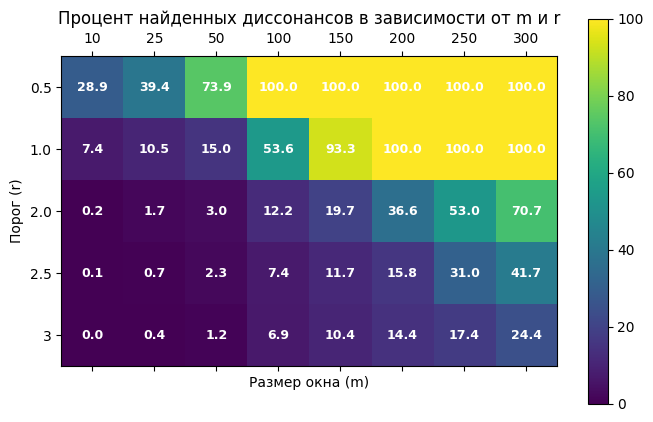

In [36]:
# Визуализация результатов (heatmap)

fig = plt.figure(figsize=(len(m_values), len(r_values)))
ax = fig.add_subplot(111)
heatmap_data = np.zeros((len(r_values), len(m_values)))
for i, r in enumerate(r_values):
    for j, m in enumerate(m_values):
        heatmap_data[i, j] = pcts[(m, r)]
cax = ax.matshow(heatmap_data, cmap='viridis')
fig.colorbar(cax)
ax.set_xticks(np.arange(len(m_values)))
ax.set_yticks(np.arange(len(r_values)))
ax.set_xticklabels(m_values)
ax.set_yticklabels(r_values)
ax.set_xlabel('Размер окна (m)')
ax.set_ylabel('Порог (r)')
ax.set_title('Процент найденных диссонансов в зависимости от m и r')


# добавляем численные значения в ячейки
for i in range(len(r_values)):
    for j in range(len(m_values)):
        val = heatmap_data[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

plt.show()

##### Визуализация результатов (графики)

In [ ]:
for (m, r), discords in results.items():
    n_win = n - m + 1
    pct = pcts[(m, r)]

    fig = plt.figure(figsize=(18, 4))
    plt.plot(nyt_data, label='NY Taxi Data')
    for discord in discords:
        start = discord
        plt.axvspan(start, start + m, color='red', alpha=0.5)
    plt.title(f'({m}, {r}) Потенциальные диссонансы: '
              f'{len(discords)} из {n_win} окон ≈ {pct:.1f}%', fontsize=12)
    plt.legend()
    plt.show()

### **3.3.** Поиск диссонансов с помощью алгоритма Merlin

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

#### **3.3.1.** Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [76]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10

In [77]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [78]:
maxL

55

In [79]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [80]:
# Используем найденные ранее диссонансы длины minL
accepted_idx   = list(dis_idx[:cound_find_dis].astype(int))
accepted_len   = [minL]*cound_find_dis
accepted_nnDist= list(dis_nnDist[:cound_find_dis].astype(float))
accepted_nn_idx= list(dis_nn_idx[:cound_find_dis].astype(int))

occupied_points = np.zeros(len(T), dtype=bool)

def is_valid_discord(start, m, occupied_points, min_unique_ratio=0.75):
    # доля точек окна, которые еще не заняты предыдущими диссонансами
    unique_ratio = np.mean(~occupied_points[start:start+m])
    return unique_ratio >= min_unique_ratio

def accept_discord(start, m, nnDist, nn_idx):
    # отметить занятость точек окна и исключить соседние окна из include
    occupied_points[start:start+m] = True
    core.apply_exclusion_zone(include, start, excl_zone, False)
    accepted_idx.append(int(start))
    accepted_len.append(int(m))
    accepted_nnDist.append(float(nnDist))
    accepted_nn_idx.append(int(nn_idx))

for s in accepted_idx:
    if s >= 0:
        occupied_points[s:s+minL] = True
        core.apply_exclusion_zone(include, s, excl_zone, False)

nnDist_by_len = {}
if cound_find_dis > 0:
    nnDist_by_len[minL] = float(np.min([d for L,d in zip(accepted_len, accepted_nnDist) if L==minL]))

for cur_m in range(minL+1, minL+5):
    if len(accepted_idx) >= topK:
        break

    # если по предыдущей длине нет nnDist>0, просто пропускаем к следующей длине
    prev_m = cur_m - 1
    if prev_m not in nnDist_by_len or nnDist_by_len[prev_m] <= 0:
        continue

    r = 0.99 * nnDist_by_len[prev_m]
    cur_len_found = []  # список nnDist найденных на текущей длине, чтобы взять min()

    # пока ни одного валидного диссонанса этой длины не добавили и глобально не набрали topK
    while (len(cur_len_found) == 0) and (len(accepted_idx) < topK):
        idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)

        # отфильтруем по правилу 75%
        added_any = False
        for s, nd, nn in zip(idxs, nndists, nn_idxs):
            if len(accepted_idx) >= topK: break
            if is_valid_discord(s, cur_m, occupied_points):
                accept_discord(s, cur_m, nd, nn)
                cur_len_found.append(float(nd))
                added_any = True

        if len(cur_len_found) > 0:
            nnDist_by_len[cur_m] = float(np.min(cur_len_found))
        else:
            # снизим порог и повторим
            r *= 0.99
            # защита от зацикливания: если r стал неприлично мал, выходим
            if r < 1e-12:
                break

for cur_m in range(minL+5, maxL+1):
    if len(accepted_idx) >= topK: break

    prev_ms = [cur_m-k for k in range(1,6)]
    if not all(mk in nnDist_by_len and nnDist_by_len[mk] > 0 for mk in prev_ms):
        continue

    prev_vals = np.array([nnDist_by_len[mk] for mk in prev_ms], dtype=float)
    mu, sigma = float(prev_vals.mean()), float(prev_vals.std(ddof=0))
    r = mu - 2.0*sigma

    cur_len_found = []

    idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)

    for s, nd, nn in zip(idxs, nndists, nn_idxs):
        if len(accepted_idx) >= topK: break
        if is_valid_discord(s, cur_m, occupied_points):
            accept_discord(s, cur_m, nd, nn)
            cur_len_found.append(float(nd))

    if len(cur_len_found) > 0:
        nnDist_by_len[cur_m] = float(np.min(cur_len_found))
    else:
        while (len(cur_len_found) == 0) and (len(accepted_idx) < topK):
            r = r - sigma
            if r <= 0:  # дальше смысла нет
                break
            idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)
            for s, nd, nn in zip(idxs, nndists, nn_idxs):
                if len(accepted_idx) >= topK: break
                if is_valid_discord(s, cur_m, occupied_points):
                    accept_discord(s, cur_m, nd, nn)
                    cur_len_found.append(float(nd))

        if len(cur_len_found) > 0:
            nnDist_by_len[cur_m] = float(np.min(cur_len_found))

print(f'Всего найдено диссонансов: {len(accepted_idx)} из {topK}')


Всего найдено диссонансов: 10 из 10


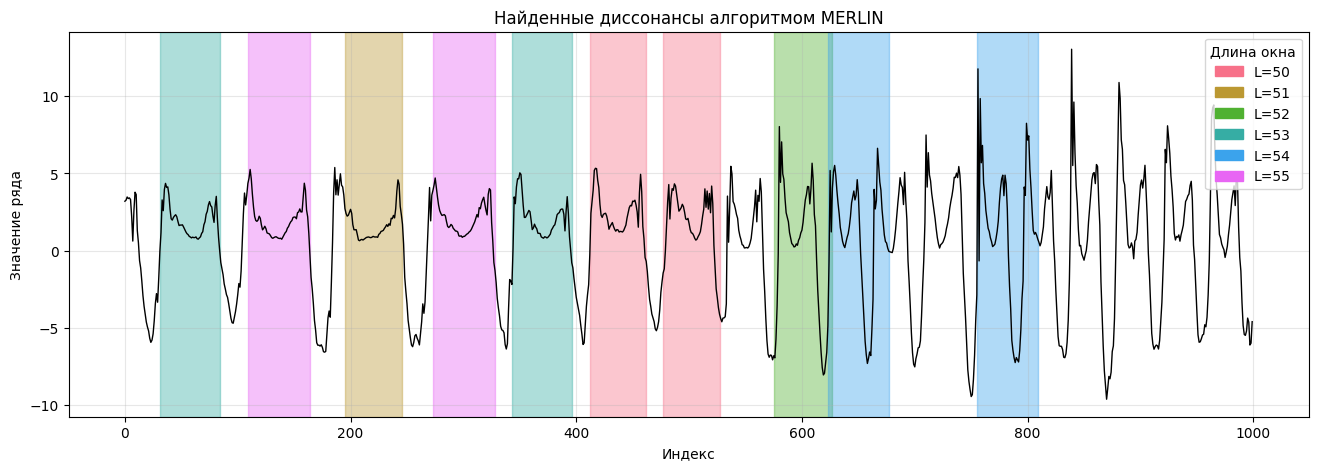

In [81]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.figure(figsize=(16, 5))
plt.plot(T, color='black', linewidth=1, label='Временной ряд')

# создадим палитру для разных длин
unique_lengths = sorted(set(accepted_len))
palette = sns.color_palette("husl", len(unique_lengths))
length_color_map = dict(zip(unique_lengths, palette))

for idx, L, dist in zip(accepted_idx, accepted_len, accepted_nnDist):
    color = length_color_map[L]
    plt.axvspan(idx, idx + L, color=color, alpha=0.4)

# легенда
patches = [mpatches.Patch(color=length_color_map[L], label=f'L={L}') for L in unique_lengths]
plt.legend(handles=patches, title='Длина окна', loc='upper right')

plt.title('Найденные диссонансы алгоритмом MERLIN')
plt.xlabel('Индекс')
plt.ylabel('Значение ряда')
plt.grid(alpha=0.3)
plt.show()


Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


In [82]:
T = nyt_data
m = 200
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10

In [83]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [84]:
maxL

220

In [85]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 3


In [86]:
# Используем найденные ранее диссонансы длины minL
accepted_idx   = list(dis_idx[:cound_find_dis].astype(int))
accepted_len   = [minL]*cound_find_dis
accepted_nnDist= list(dis_nnDist[:cound_find_dis].astype(float))
accepted_nn_idx= list(dis_nn_idx[:cound_find_dis].astype(int))

occupied_points = np.zeros(len(T), dtype=bool)

def is_valid_discord(start, m, occupied_points, min_unique_ratio=0.75):
    # доля точек окна, которые еще не заняты предыдущими диссонансами
    unique_ratio = np.mean(~occupied_points[start:start+m])
    return unique_ratio >= min_unique_ratio

def accept_discord(start, m, nnDist, nn_idx):
    # отметить занятость точек окна и исключить соседние окна из include
    occupied_points[start:start+m] = True
    core.apply_exclusion_zone(include, start, excl_zone, False)
    accepted_idx.append(int(start))
    accepted_len.append(int(m))
    accepted_nnDist.append(float(nnDist))
    accepted_nn_idx.append(int(nn_idx))

for s in accepted_idx:
    if s >= 0:
        occupied_points[s:s+minL] = True
        core.apply_exclusion_zone(include, s, excl_zone, False)

nnDist_by_len = {}
if cound_find_dis > 0:
    nnDist_by_len[minL] = float(np.min([d for L,d in zip(accepted_len, accepted_nnDist) if L==minL]))

for cur_m in range(minL+1, minL+5):
    if len(accepted_idx) >= topK:
        break

    # если по предыдущей длине нет nnDist>0, просто пропускаем к следующей длине
    prev_m = cur_m - 1
    if prev_m not in nnDist_by_len or nnDist_by_len[prev_m] <= 0:
        continue

    r = 0.99 * nnDist_by_len[prev_m]
    cur_len_found = []  # список nnDist найденных на текущей длине, чтобы взять min()

    # пока ни одного валидного диссонанса этой длины не добавили и глобально не набрали topK
    while (len(cur_len_found) == 0) and (len(accepted_idx) < topK):
        idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)

        # отфильтруем по правилу 75%
        added_any = False
        for s, nd, nn in zip(idxs, nndists, nn_idxs):
            if len(accepted_idx) >= topK: break
            if is_valid_discord(s, cur_m, occupied_points):
                accept_discord(s, cur_m, nd, nn)
                cur_len_found.append(float(nd))
                added_any = True

        if len(cur_len_found) > 0:
            nnDist_by_len[cur_m] = float(np.min(cur_len_found))
        else:
            # снизим порог и повторим
            r *= 0.99
            # защита от зацикливания: если r стал неприлично мал, выходим
            if r < 1e-12:
                break

for cur_m in range(minL+5, maxL+1):
    if len(accepted_idx) >= topK: break

    prev_ms = [cur_m-k for k in range(1,6)]
    if not all(mk in nnDist_by_len and nnDist_by_len[mk] > 0 for mk in prev_ms):
        continue

    prev_vals = np.array([nnDist_by_len[mk] for mk in prev_ms], dtype=float)
    mu, sigma = float(prev_vals.mean()), float(prev_vals.std(ddof=0))
    r = mu - 2.0*sigma

    cur_len_found = []

    idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)

    for s, nd, nn in zip(idxs, nndists, nn_idxs):
        if len(accepted_idx) >= topK: break
        if is_valid_discord(s, cur_m, occupied_points):
            accept_discord(s, cur_m, nd, nn)
            cur_len_found.append(float(nd))

    if len(cur_len_found) > 0:
        nnDist_by_len[cur_m] = float(np.min(cur_len_found))
    else:
        while (len(cur_len_found) == 0) and (len(accepted_idx) < topK):
            r = r - sigma
            if r <= 0:  # дальше смысла нет
                break
            idxs, nndists, nn_idxs = DRAG(data=T, m=cur_m, r=r, include=include)
            for s, nd, nn in zip(idxs, nndists, nn_idxs):
                if len(accepted_idx) >= topK: break
                if is_valid_discord(s, cur_m, occupied_points):
                    accept_discord(s, cur_m, nd, nn)
                    cur_len_found.append(float(nd))

        if len(cur_len_found) > 0:
            nnDist_by_len[cur_m] = float(np.min(cur_len_found))

print(f'Всего найдено диссонансов: {len(accepted_idx)} из {topK}')


Всего найдено диссонансов: 10 из 10


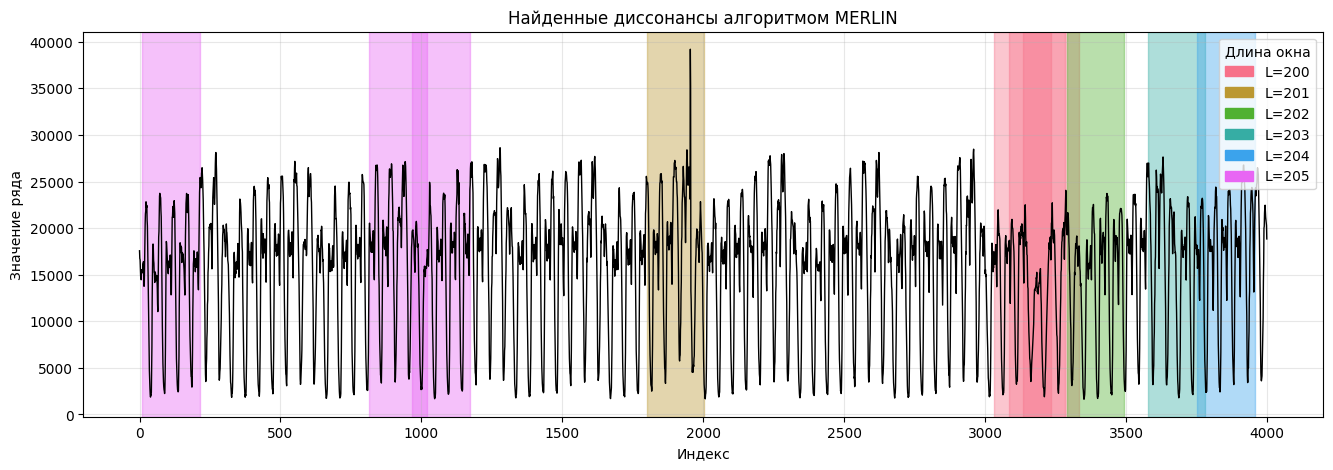

In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.figure(figsize=(16, 5))
plt.plot(T, color='black', linewidth=1, label='Временной ряд')

# создадим палитру для разных длин
unique_lengths = sorted(set(accepted_len))
palette = sns.color_palette("husl", len(unique_lengths))
length_color_map = dict(zip(unique_lengths, palette))

for idx, L, dist in zip(accepted_idx, accepted_len, accepted_nnDist):
    color = length_color_map[L]
    plt.axvspan(idx, idx + L, color=color, alpha=0.4)

# легенда
patches = [mpatches.Patch(color=length_color_map[L], label=f'L={L}') for L in unique_lengths]
plt.legend(handles=patches, title='Длина окна', loc='upper right')

plt.title('Найденные диссонансы алгоритмом MERLIN')
plt.xlabel('Индекс')
plt.ylabel('Значение ряда')
plt.grid(alpha=0.3)
plt.show()
